In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings

# --- Global Style Setup ---
warnings.filterwarnings('ignore')
sns.set_theme(style="ticks", palette="bright")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# -----------------------------------------------------------------------------
# STEP 1: DATA LOADING & PREPARATION
# -----------------------------------------------------------------------------
try:
    df = pd.read_csv('heart.csv')
    cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
    print("✓ Heart dataset loaded for Student 4.")
except Exception as e:
    print(f"Error: {e}")

✓ Heart dataset loaded for Student 4.


In [ ]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


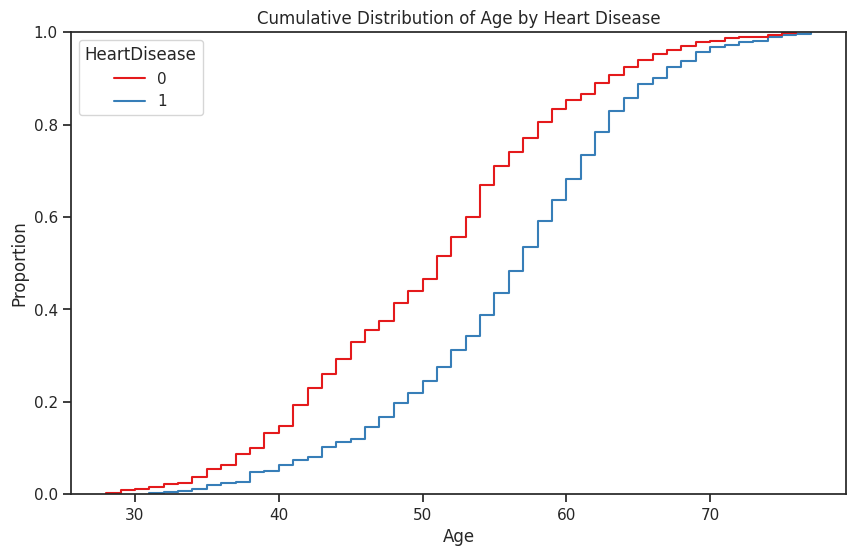

In [ ]:
plt.figure()
sns.ecdfplot(data=df, x="Age", hue="HeartDisease", palette="Set1")
plt.title('Cumulative Distribution of Age by Heart Disease')
plt.show()

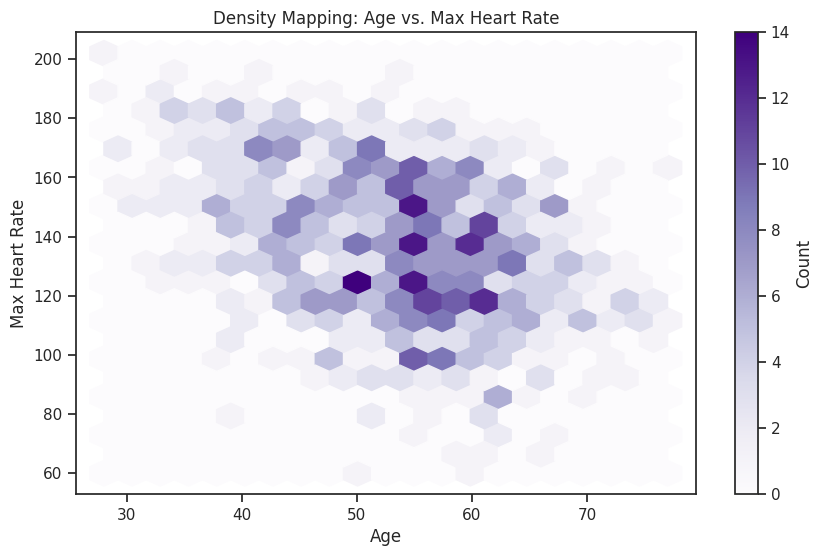

In [ ]:
plt.figure()
plt.hexbin(df['Age'], df['MaxHR'], gridsize=20, cmap='Purples')
plt.colorbar(label='Count')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.title('Density Mapping: Age vs. Max Heart Rate')
plt.show()

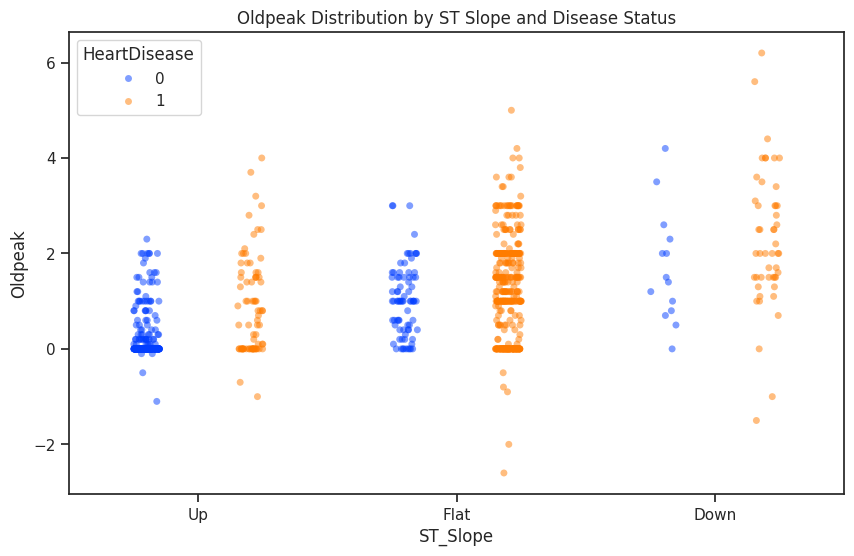

In [ ]:
plt.figure()
sns.stripplot(x='ST_Slope', y='Oldpeak', hue='HeartDisease', data=df, jitter=True, alpha=0.5, dodge=True)
plt.title('Oldpeak Distribution by ST Slope and Disease Status')
plt.show()

<Figure size 1000x600 with 0 Axes>

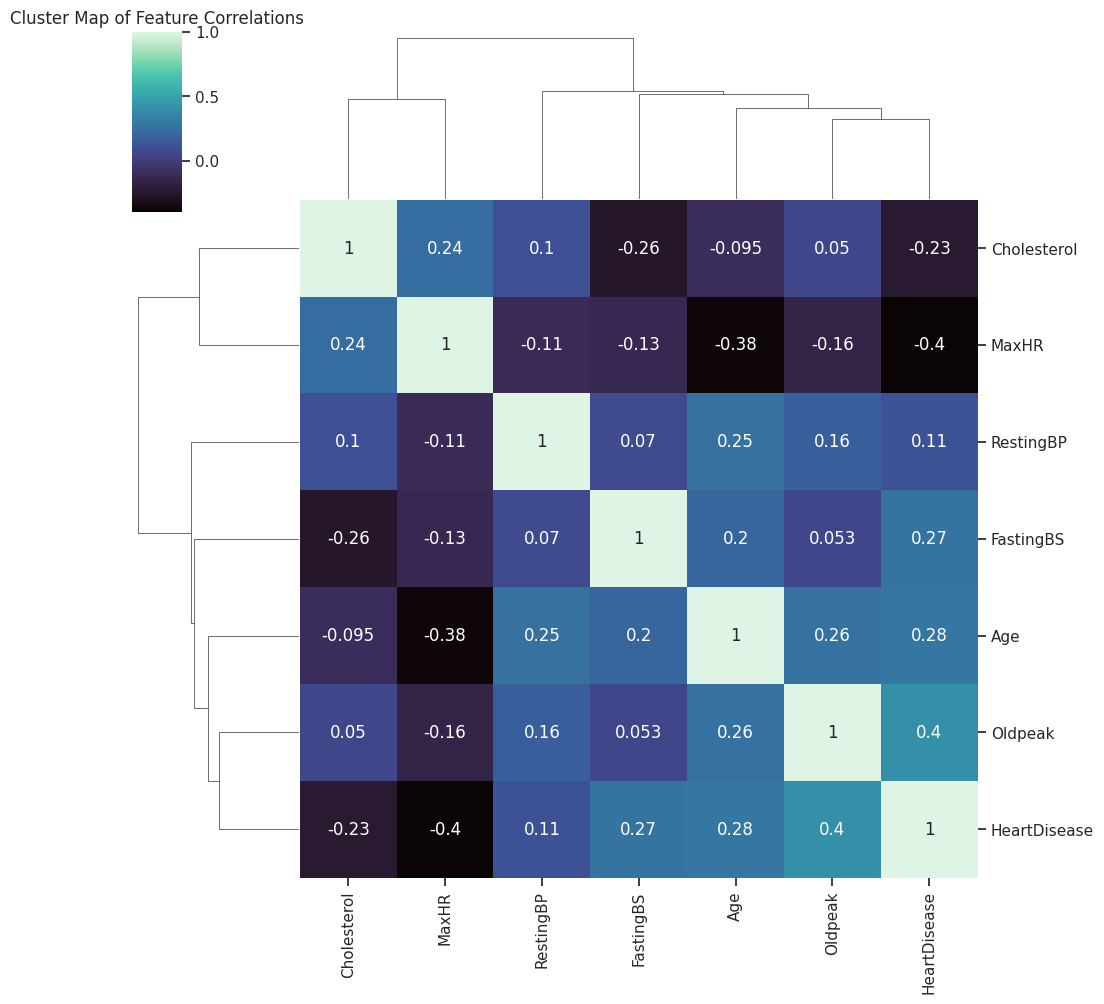

In [ ]:
plt.figure()
numeric_only = df.select_dtypes(include=[np.number])
sns.clustermap(numeric_only.corr(), annot=True, cmap='mako')
plt.title('Cluster Map of Feature Correlations')
plt.show()

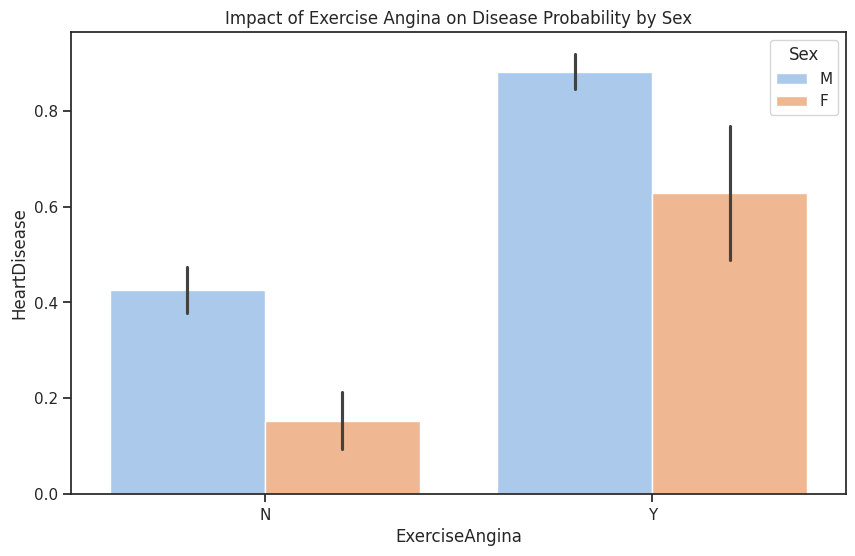

In [ ]:
plt.figure()
sns.barplot(x='ExerciseAngina', y='HeartDisease', hue='Sex', data=df, palette='pastel')
plt.title('Impact of Exercise Angina on Disease Probability by Sex')
plt.show()

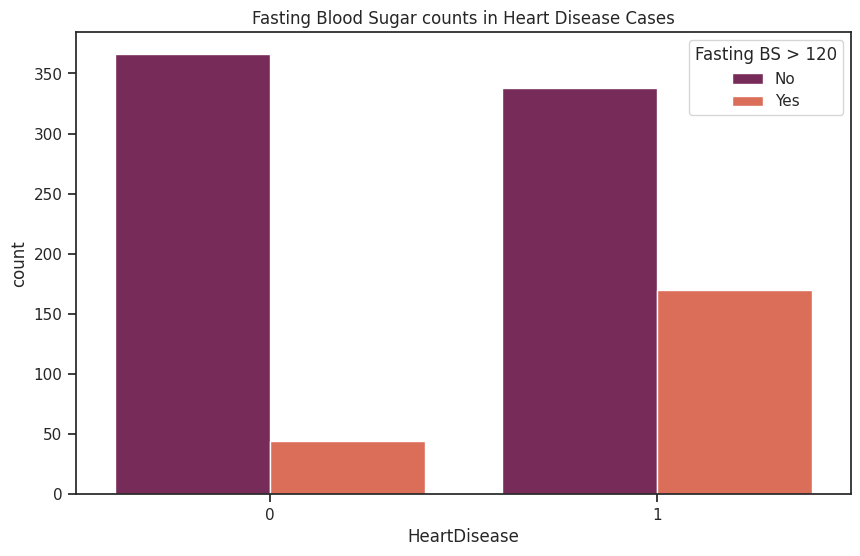

In [ ]:
plt.figure()
sns.countplot(x='HeartDisease', hue='FastingBS', data=df, palette='rocket')
plt.legend(title='Fasting BS > 120', labels=['No', 'Yes'])
plt.title('Fasting Blood Sugar counts in Heart Disease Cases')
plt.show()

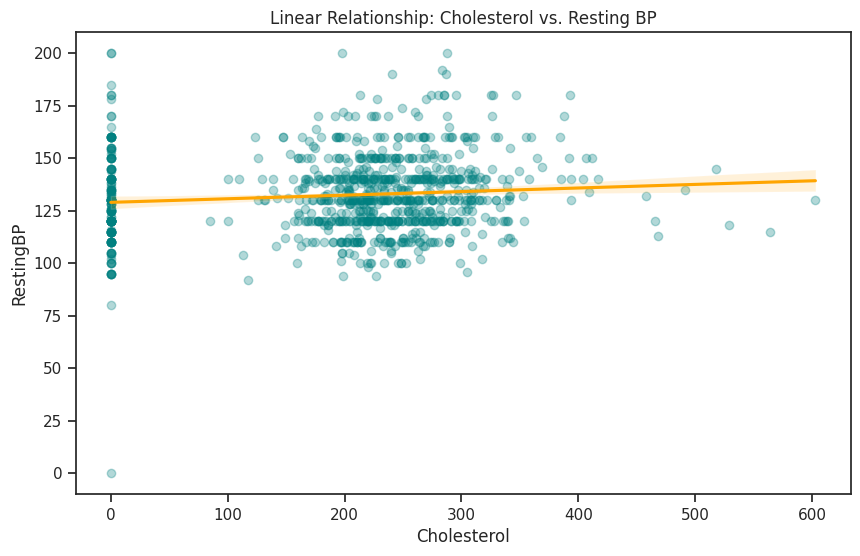

In [ ]:
plt.figure()
sns.regplot(x='Cholesterol', y='RestingBP', data=df, scatter_kws={'color':'teal', 'alpha':0.3}, line_kws={'color':'orange'})
plt.title('Linear Relationship: Cholesterol vs. Resting BP')
plt.show()

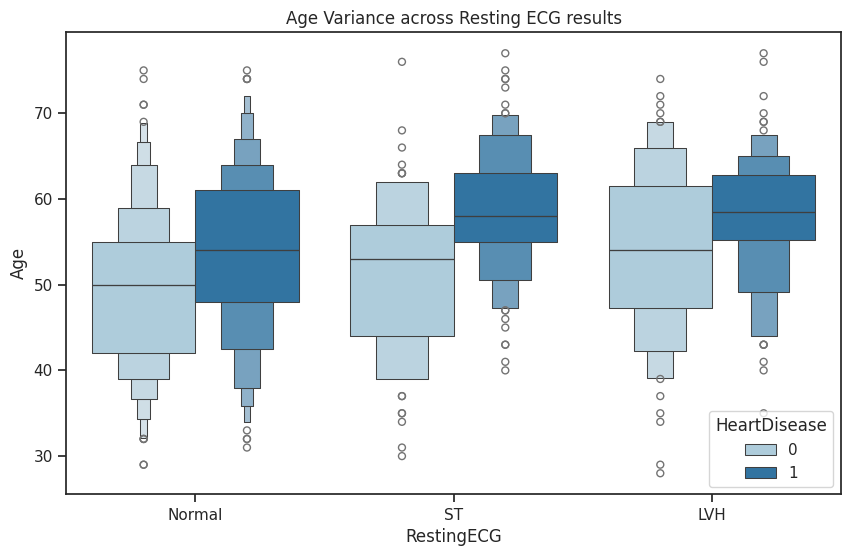

In [ ]:
plt.figure()
sns.boxenplot(x='RestingECG', y='Age', hue='HeartDisease', data=df, palette='Paired')
plt.title('Age Variance across Resting ECG results')
plt.show()

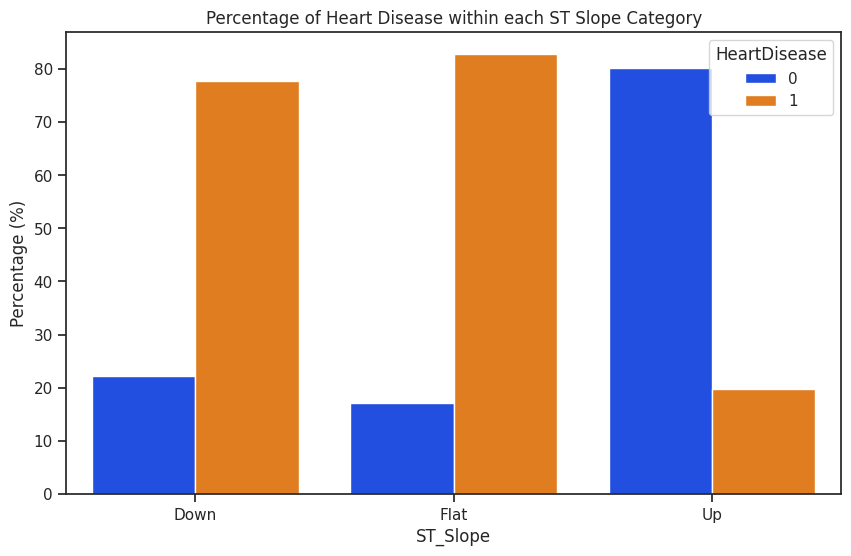

In [ ]:
st_counts = (df.groupby(['ST_Slope'])['HeartDisease']
                     .value_counts(normalize=True)
                     .rename('percentage')
                     .mul(100)
                     .reset_index())
plt.figure()
sns.barplot(x='ST_Slope', y='percentage', hue='HeartDisease', data=st_counts)
plt.title('Percentage of Heart Disease within each ST Slope Category')
plt.ylabel('Percentage (%)')
plt.show()

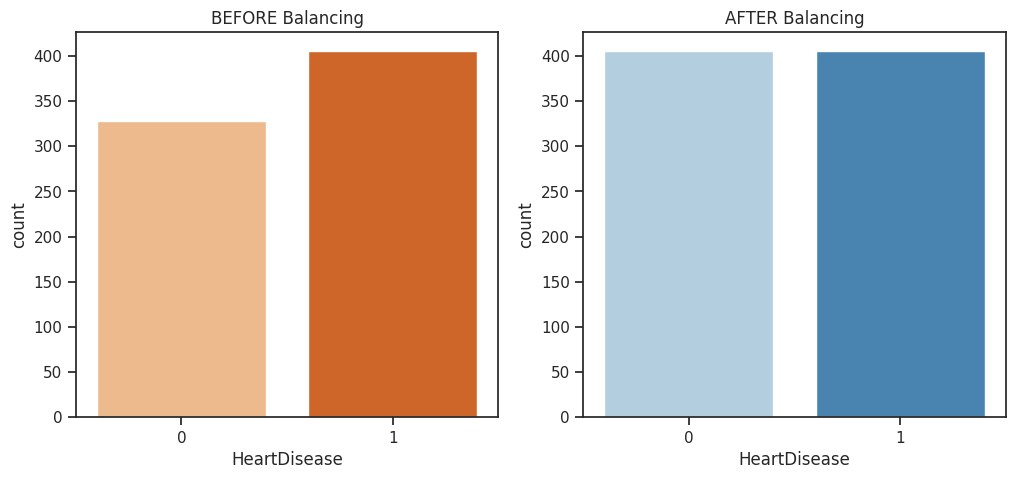

In [ ]:
# -----------------------------------------------------------------------------
# STEP 3: PRE-PROCESSING & OVERSAMPLING
# -----------------------------------------------------------------------------
# Encoding
df_encoded = df.copy()
le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

# Split
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Manual Oversampling (Handling class imbalance)
train_combined = pd.concat([X_train_raw, y_train_raw], axis=1)
df_maj = train_combined[train_combined.HeartDisease == 1]
df_min = train_combined[train_combined.HeartDisease == 0]

df_min_upsampled = resample(df_min, replace=True, n_samples=len(df_maj), random_state=42)
train_balanced = pd.concat([df_maj, df_min_upsampled])

# Visualize Balance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='HeartDisease', data=train_combined, ax=ax1, palette='Oranges')
ax1.set_title('BEFORE Balancing')
sns.countplot(x='HeartDisease', data=train_balanced, ax=ax2, palette='Blues')
ax2.set_title('AFTER Balancing')
plt.show()

X_train = train_balanced.drop('HeartDisease', axis=1)
y_train = train_balanced['HeartDisease']

# Scaling (Essential for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# -----------------------------------------------------------------------------
# STEP 2: APPLYING UPDATED MODELS
# -----------------------------------------------------------------------------

# 1. Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# 2. Support Vector Classifier (SVC)
# Note: Using SVC (Classification) instead of SVR to match your metric requirements
svc_model = SVC(kernel='linear')
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)


--- Logistic Regression Performance ---
Accuracy:  0.8587
Precision: 0.8725
Recall:    0.8725
F1 Score:  0.8725

--- Support Vector Classifier Performance ---
Accuracy:  0.8587
Precision: 0.8585
Recall:    0.8922
F1 Score:  0.8750


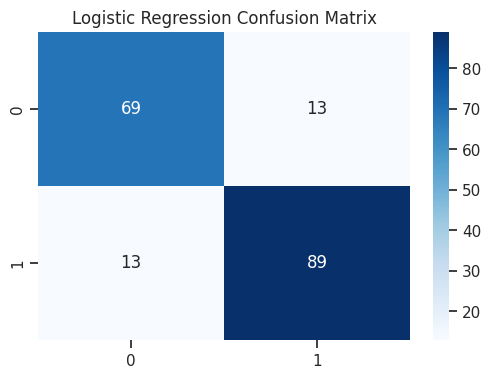

In [ ]:
# -----------------------------------------------------------------------------
# STEP 3: PERFORMANCE EVALUATION (Classification Metrics Only)
# -----------------------------------------------------------------------------

def evaluate_classification(y_true, y_pred, model_name):
    print(f"\n--- {model_name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")

evaluate_classification(y_test, y_pred_log, "Logistic Regression")
evaluate_classification(y_test, y_pred_svc, "Support Vector Classifier")

# Visualization: Confusion Matrix for Logistic Regression
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [ ]:
# -----------------------------------------------------------------------------
# STEP 2: MODEL TRAINING & METRIC COLLECTION
# -----------------------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(),
    "SVC (Linear)": SVC(kernel='linear')
}

results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    results_list.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions)
    })

In [ ]:
# Create Rank Table
results_df = pd.DataFrame(results_list)
results_df['Rank'] = results_df['Accuracy'].rank(ascending=False).astype(int)
results_df = results_df.sort_values(by='Rank')

print("\n--- Model Performance Rank Table ---")
print(results_df.to_string(index=False))


--- Model Performance Rank Table ---
              Model  Accuracy  Precision   Recall  F1-Score  Rank
Logistic Regression  0.858696   0.872549 0.872549  0.872549     1
       SVC (Linear)  0.858696   0.858491 0.892157  0.875000     1


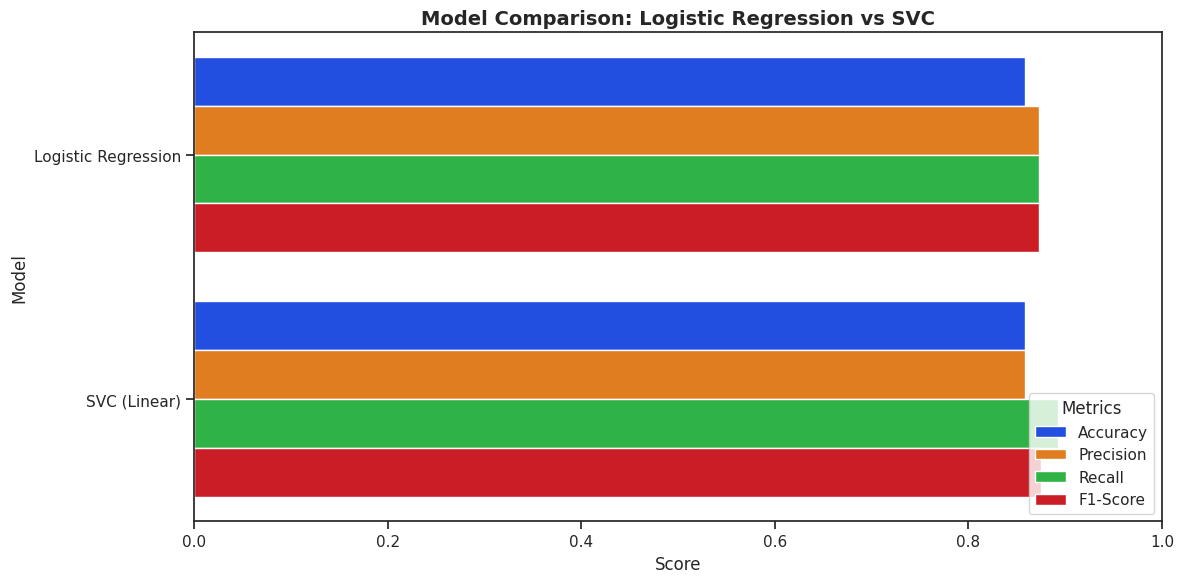

In [ ]:
# Comparison Visualization
results_melted = results_df.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1-Score"])

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x="value", y="Model", hue="variable")
plt.title("Model Comparison: Logistic Regression vs SVC", fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)
plt.xlabel("Score")
plt.legend(title="Metrics", loc='lower right')
plt.tight_layout()
plt.show()